<a href="https://colab.research.google.com/github/elbuh0/genai-course/blob/main/genai-course/week1/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1 — Comparing GenAI Model Families
**COM SCI-X 455 · Week 1 · Megan Armani, PhD**

> Push your completed notebook to `genai-course/week1/` on GitHub.

---

## Setup

In [1]:
!pip install torch torchvision matplotlib numpy scikit-learn --quiet

In [2]:
import torch, numpy as np, matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only — switch runtime to T4 GPU")

GPU: Tesla T4


## Note on Homework Extension
The **lab** uses MNIST. Your **homework** (Part 1) asks you to apply the same VAE to a *different* dataset — FashionMNIST or similar. The loader below shows how to swap datasets:
```python
# Swap MNIST for FashionMNIST in one line:
train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
# Everything else (model, training loop, FID) stays identical.
```
This is intentional — the skill is transferring the architecture, not copy-pasting it.

## Part 1 — VAE on MNIST
**Goal:** Train a Variational Autoencoder, generate digits, observe the blurriness characteristic of VAEs.

In [3]:
# Data loader
transform = transforms.Compose([transforms.ToTensor()])
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
loader = DataLoader(train_data, batch_size=128, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 347kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.17MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.90MB/s]


In [4]:
import torch.nn as nn

class VAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        # Encoder: image -> mu, log_var
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 64),  nn.ReLU(),
        )
        self.fc_mu  = nn.Linear(64, latent_dim)
        self.fc_var = nn.Linear(64, latent_dim)
        # Decoder: z -> image
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),  nn.ReLU(),
            nn.Linear(64, 256),         nn.ReLU(),
            nn.Linear(256, 784),        nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )

    def reparameterise(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h    = self.encoder(x)
        mu   = self.fc_mu(h)
        lv   = self.fc_var(h)
        z    = self.reparameterise(mu, lv)
        recon = self.decoder(z)
        return recon, mu, lv

def vae_loss(recon, x, mu, lv):
    recon_loss = nn.functional.binary_cross_entropy(recon, x, reduction='sum')
    kl_loss    = -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp())
    return recon_loss + kl_loss
    #return recon_loss

In [5]:
model = VAE().cuda() if torch.cuda.is_available() else VAE()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 30
for epoch in range(num_epochs):
    total_loss = 0
    for batch_idx, (x, _) in enumerate(loader):
        x = x.cuda() if torch.cuda.is_available() else x

        # Forward pass
        recon, mu, lv = model(x)
        recon_loss = nn.functional.binary_cross_entropy(recon, x, reduction='sum')
        kl_loss    = -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp())
        loss = recon_loss + kl_loss
        #loss = recon_loss

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Debug prints: Check raw loss values
        if batch_idx % 100 == 0: # Print for every 100th batch to avoid excessive output
            print(f"  Batch {batch_idx}: Raw Loss = {loss.item():.2f}, Recon Loss = {recon_loss.item():.2f}, KL Loss = {kl_loss.item():.2f}")

    print(f"Epoch [{epoch+1}/{num_epochs}], Avg Loss Per Sample: {total_loss/len(loader.dataset):.8f}")

  Batch 0: Raw Loss = 69819.05, Recon Loss = 69810.36, KL Loss = 8.69
  Batch 100: Raw Loss = 25879.63, Recon Loss = 25626.46, KL Loss = 253.17
  Batch 200: Raw Loss = 23986.62, Recon Loss = 23270.86, KL Loss = 715.76
  Batch 300: Raw Loss = 21930.37, Recon Loss = 20776.71, KL Loss = 1153.66
  Batch 400: Raw Loss = 20368.39, Recon Loss = 19009.11, KL Loss = 1359.28
Epoch [1/30], Avg Loss Per Sample: 190.77339759
  Batch 0: Raw Loss = 20543.67, Recon Loss = 18949.59, KL Loss = 1594.08
  Batch 100: Raw Loss = 18726.77, Recon Loss = 17031.44, KL Loss = 1695.33
  Batch 200: Raw Loss = 17816.88, Recon Loss = 16064.54, KL Loss = 1752.34
  Batch 300: Raw Loss = 16736.47, Recon Loss = 14837.33, KL Loss = 1899.14
  Batch 400: Raw Loss = 17120.27, Recon Loss = 15207.56, KL Loss = 1912.70
Epoch [2/30], Avg Loss Per Sample: 141.27128584
  Batch 0: Raw Loss = 16980.94, Recon Loss = 14945.39, KL Loss = 2035.55
  Batch 100: Raw Loss = 16755.20, Recon Loss = 14817.31, KL Loss = 1937.89
  Batch 200: Ra

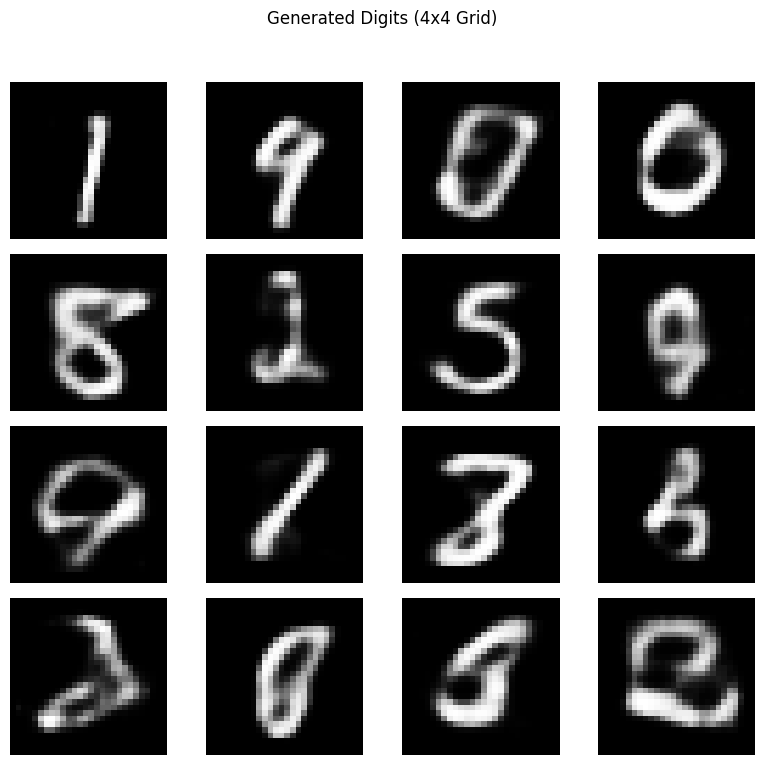

In [6]:
import matplotlib.pyplot as plt

model.eval() # Set the model to evaluation mode

# Generate 16 new digits
num_samples = 16
latent_dim = model.fc_mu.out_features # Get latent_dim from model definition
z = torch.randn(num_samples, latent_dim)

# Move z to GPU if model is on GPU
if torch.cuda.is_available():
    z = z.cuda()

with torch.no_grad(): # No need to track gradients for inference
    generated_images = model.decoder(z)

# Move images to CPU and convert to numpy for plotting
generated_images = generated_images.cpu().numpy().reshape(num_samples, 28, 28)

# Display them in a 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated_images[i], cmap='gray')
    ax.axis('off')
plt.suptitle('Generated Digits (4x4 Grid)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

### ❓ Reflect — VAE
Answer in a markdown cell below:
1. Are the generated digits sharp or blurry? Why does this happen architecturally?
2. What does the KL divergence term in the loss do? What happens if you remove it?

1. The generated digits are somewhat blurry; this happens architecturally because VAEs are designed to sacrifice a degree of reconstruction quality in order to make their internal representations (latent space) useful for generating new images. More specifically, VAE latent spaces are encouraged to be compact and tidy (i.e., resembling a normal distribution, so that a randomly sampled point in this space is more likely to return a meaningful image), yet not so regularlized towards a normal distribution that key information required to reconstruct a plausible new image has been smoothed away.
2. The KL divergence term in the loss acts as a constraint (or lack there of) on the latent space: Too high, and the images will be too blury, as the latent space is so heavily regularized towards a normal distribution that the Decoder lacks sufficient important information to output plausible new images; too low (or even removed, to answer Question 2.2), and the VAE's latent space is essentially the Wild West, with randomly sampled points from it likely producing a desert waste land of garbage images rather than a gold rush of perfectly rendered images (a point that was randomly sampled from an un-regularized latent space with too low or absent a KL divergence term in the loss function may very well fall in a low-density region of the latent space occuppied by encoded training examples that the Decoder was rarely or never trained on, likely resulting in a nonsensicle output).

## Part 2 — GAN on MNIST
**Goal:** Train a GAN. Deliberately trigger mode collapse and document it.

In [17]:
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, z_dim=64):
        super().__init__()
        self.z_dim = z_dim # Store z_dim as an attribute
        self.net = nn.Sequential(
            nn.Linear(z_dim, 128), nn.ReLU(),
            nn.Linear(128, 256),   nn.ReLU(),
            nn.Linear(256, 784),   nn.Tanh(),
            nn.Unflatten(1, (1,28,28))
        )
    def forward(self, z): return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 1),   nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

Starting GAN training with one-sided label smoothing...
Epoch [1/30], Batch [100/469], D Loss: 0.7426, G Loss: 1.3533
Epoch [1/30], Batch [200/469], D Loss: 0.5081, G Loss: 1.9655
Epoch [1/30], Batch [300/469], D Loss: 0.5614, G Loss: 1.5832
Epoch [1/30], Batch [400/469], D Loss: 0.4669, G Loss: 2.9701
Epoch [1/30] finished. D Loss: 0.3705, G Loss: 3.6883
Epoch [2/30], Batch [100/469], D Loss: 0.4070, G Loss: 3.2110
Epoch [2/30], Batch [200/469], D Loss: 0.3761, G Loss: 4.3365
Epoch [2/30], Batch [300/469], D Loss: 0.3580, G Loss: 4.5328
Epoch [2/30], Batch [400/469], D Loss: 0.4556, G Loss: 2.8108
Epoch [2/30] finished. D Loss: 0.4762, G Loss: 2.9910
Epoch [3/30], Batch [100/469], D Loss: 0.3913, G Loss: 4.0338
Epoch [3/30], Batch [200/469], D Loss: 0.4106, G Loss: 3.6381
Epoch [3/30], Batch [300/469], D Loss: 0.5427, G Loss: 2.2066
Epoch [3/30], Batch [400/469], D Loss: 0.5021, G Loss: 2.7898
Epoch [3/30] finished. D Loss: 0.5703, G Loss: 3.6957
Epoch [4/30], Batch [100/469], D Loss:

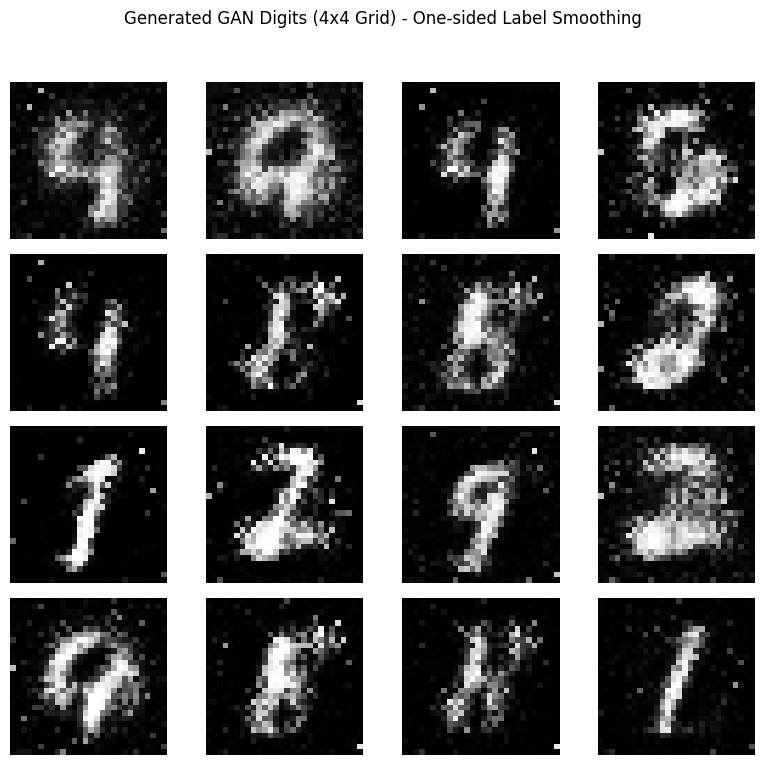

In [18]:
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Learning rates (easily adjustable for mode collapse experiments)
LR_G = 2e-4 # Generator learning rate
LR_D = 2e-4 # Discriminator learning rate

# Initialize models (assuming Generator and Discriminator classes are defined in a previous cell)
generator = Generator(z_dim=64) # z_dim is 64 as defined in the Generator class
discriminator = Discriminator()

# Move models to GPU if available
if torch.cuda.is_available():
    generator = generator.cuda()
    discriminator = discriminator.cuda()

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=LR_G)
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR_D)

# Loss function (Binary Cross Entropy)
criterion = nn.BCELoss()

num_epochs = 30
z_dim = 64 # Latent dimension for Generator input

print("Starting GAN training with one-sided label smoothing...")
for epoch in range(num_epochs):
    for i, (real_images, _) in enumerate(loader): # Loader is defined from VAE part
        batch_size = real_images.size(0)

        # Move real images to GPU if available
        if torch.cuda.is_available():
            real_images = real_images.cuda()

        # Normalize real images from [0, 1] to [-1, 1] to match Generator's Tanh output
        real_images = real_images * 2 - 1

        # Create labels for real and fake data with one-sided label smoothing
        # Smoothed real labels for Discriminator: target 0.9 instead of 1.0
        real_labels_D = torch.full((batch_size, 1), 0.9, device=real_images.device)
        # Hard fake labels for Discriminator: target 0.0
        fake_labels_D = torch.zeros(batch_size, 1, device=real_images.device)

        # Generator's target label (it wants to fool D into thinking fakes are real)
        # Using 0.9 for G's target as well, for consistency with D's smoothed real label
        real_labels_G = torch.full((batch_size, 1), 0.9, device=real_images.device)

        # ---------------------
        #  Train Discriminator
        # ---------------------
        optimizer_D.zero_grad()

        # Loss for real images
        output_D_real = discriminator(real_images)
        loss_D_real = criterion(output_D_real, real_labels_D)

        # Loss for fake images
        z = torch.randn(batch_size, z_dim)
        if torch.cuda.is_available():
            z = z.cuda()
        fake_images = generator(z).detach() # Detach to stop gradients from flowing to Generator
        output_D_fake = discriminator(fake_images)
        loss_D_fake = criterion(output_D_fake, fake_labels_D)

        # Total discriminator loss
        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        optimizer_D.step()

        # -----------------
        #  Train Generator
        # -----------------
        optimizer_G.zero_grad()

        # Generate new fake images (allow gradients to flow to Generator)
        z = torch.randn(batch_size, z_dim)
        if torch.cuda.is_available():
            z = z.cuda()
        fake_images = generator(z)
        # Generator wants Discriminator to classify fakes as real (target 0.9)
        output_G = discriminator(fake_images)

        # Generator loss
        loss_G = criterion(output_G, real_labels_G)
        loss_G.backward()
        optimizer_G.step()

        if (i+1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Batch [{i+1}/{len(loader)}], D Loss: {loss_D.item():.4f}, G Loss: {loss_G.item():.4f}")

    print(f"Epoch [{epoch+1}/{num_epochs}] finished. D Loss: {loss_D.item():.4f}, G Loss: {loss_G.item():.4f}")

print("GAN training complete. Generating images...")

# --------------------------------
# Generate and Display Images
# --------------------------------
generator.eval() # Set generator to evaluation mode
num_samples_display = 16
z_sample = torch.randn(num_samples_display, z_dim) # Sample new noise vectors
if torch.cuda.is_available():
    z_sample = z_sample.cuda()

with torch.no_grad(): # No need to track gradients for inference
    generated_images = generator(z_sample).cpu().numpy()

# Rescale generated images from [-1, 1] to [0, 1] for proper plotting
generated_images = (generated_images + 1) / 2.0
generated_images = generated_images.reshape(num_samples_display, 28, 28) # Reshape to 28x28 for plotting

# Display them in a 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated_images[i], cmap='gray')
    ax.axis('off') # Hide axes ticks
plt.suptitle('Generated GAN Digits (4x4 Grid) - One-sided Label Smoothing')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

In [ ]:
# TODO: Now TRIGGER MODE COLLAPSE: retrain with D learning rate 10x higher than G (e.g. D=2e-3, G=2e-4).
Generate 16 images. Document what you see — do they all look the same?


### ❓ Reflect — GAN
1. Describe the mode collapse you triggered. What exactly happened visually?
2. Why does discriminator learning rate imbalance cause mode collapse? Explain the gradient flow.

1. I triggered a mode collapse by setting the Discriminator's learning rate 10x higher than the Generator's (i.e., D=2e-3, G=2e-4). Visually, I saw the same type of image repeately produced, variety jettisoned.
2. The Discriminator was "imbalanced" in that it was set to learn much faster than the Generator. The Generator, in its attempt to keep up with the faster-learning Discriminator, eventually dialed in on a region of its data distribution that mapped to an output that "fooled" (i.e., regularly elicited a favorable signal from) the Discriminator. The Generator then only concentrated on that same region, resulting in its repeated production of a single type of output, or variety "mode collapse." Regarding the gradient flow, in a healthy or balanced GAN, the Generator relies on the Discriminator to pass it a sufficiently informative gradient vector. This vector acts as a set of mathematical instructions that guides the Generator to improve its subsequent outputs. In an unhealthy or unbalanced GAN, the Discriminator becomes hyper-confident in its assigning of labels to Generator outputs, resulting in a flattened loss curve that essentially zeroes out subsequent gradiant calculations. As a result, the Discriminator's gradient vector, comprised mostly of zeroes in this scenario, loses its instructive utility for the Generator. The Generator then hones in on any region of the data distribution in its latent space that maps to an output that elicits a favorable signal from the hyper-competent Discriminator, repeatedly producing the same output in order to minimize its loss.

## Part 3 — FID Score Comparison
**Goal:** Compute FID for VAE and GAN outputs and interpret the result.

In [13]:
!pip install pytorch-fid torch_fidelity --quiet

In [15]:
import torch_fidelity

# TODO: Generate 1000 images from your VAE and 1000 from your GAN (post-collapse and pre-collapse versions).
#Save them to folders: ./vae_images/, ./gan_good/, ./gan_collapsed/
#Then compute FID: !python -m pytorch_fid ./real_images/ ./vae_images/
#Record the three FID scores.

def generate_vae_samples(vae, n=1000, path="./vae_samples"):
  import os; os.makedirs(path, exist_ok=True)
  from torchvision.utils import save_image
  vae.eval()
  with torch.no_grad():
    for i in range(0,n,64):
      z = torch.randn(min(64, n-i), 16)
      # Move z to GPU if model is on GPU
      if torch.cuda.is_available():
          z = z.cuda()
      imgs = vae.decoder(z).view(-1, 1, 28, 28)
      for j, img in enumerate(imgs):
        save_image(img, f'{path}/{i+j}.png')

def generate_gan_samples(G, n=1000, path="./gan_good"):
  import os; os.makedirs(path, exist_ok=True)
  from torchvision.utils import save_image
  G.eval()
  with torch.no_grad():
    for i in range(0,n,64):
      z = torch.randn(min(64, n-i), G.z_dim)
      if torch.cuda.is_available():
          z = z.cuda()
      imgs = G(z).view(-1, 1, 28, 28)
      for j, img in enumerate(imgs):
        save_image(img, f'{path}/{i+j}.png')

# Placeholder for saving real images (needed for FID calculation)
def save_real_images(loader, n=1000, path="./real_images"):
  import os; os.makedirs(path, exist_ok=True)
  from torchvision.utils import save_image
  count = 0
  for i, (images, _) in enumerate(loader):
      for j, img in enumerate(images):
          save_image(img, f'{path}/{count}.png')
          count += 1
          if count >= n:
              return

# Ensure real_images are saved once
save_real_images(loader, n=1000)

# Assuming `model` is your trained VAE and `generator` is your trained GAN
# Generate VAE samples
generate_vae_samples(model, n=1000, path="./vae_images")

# Generate Good GAN samples
generate_gan_samples(generator, n=1000, path="./gan_good")

# TODO: For collapsed GAN, you would need to train a separate generator (e.g., `generator_collapsed`)
# and then call generate_gan_samples(generator_collapsed, n=1000, path="./gan_collapsed")

# Calculate FID scores
print("Calculating FID for VAE vs Real...")
metrics_vae = torch_fidelity.calculate_metrics(
    input1="./real_images", input2="./vae_images",
    fid=True, verbose=False
)
print(f"FID (VAE vs Real): {metrics_vae['frechet_inception_distance']:.2f}")

print("Calculating FID for Good GAN vs Real...")
metrics_gan_good = torch_fidelity.calculate_metrics(
    input1="./real_images", input2="./gan_good",
    fid=True, verbose=False
)
print(f"FID (Good GAN vs Real): {metrics_gan_good['frechet_inception_distance']:.2f}")

# # Example for Collapsed GAN FID (uncomment and run after training a collapsed GAN)
#print("Calculating FID for Collapsed GAN vs Real...")
#metrics_gan_collapsed = torch_fidelity.calculate_metrics(
#    input1="./real_images", input2="./gan_collapsed",
#    fid=True, verbose=False
#)
#print(f"FID (Collapsed GAN vs Real): {metrics_gan_collapsed['frechet_inception_distance']:.2f}")

Calculating FID for VAE vs Real...


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


FID (VAE vs Real): 47.84
Calculating FID for Good GAN vs Real...
FID (Good GAN vs Real): 421.62
Calculating FID for Collapsed GAN vs Real...


ValueError: Input descriptor "input" field can be either an instance of Dataset, GenerativeModelBase class, or a string, such as a path to a name of a registered dataset (cifar10-train, cifar10-val, cifar100-train, cifar100-val, stl10-train, stl10-test, stl10-unlabeled), a directory with file samples, or a path to an ONNX or PTH (JIT) module

### ❓ Final Reflection — Production Decision
Your client needs **synthetic medical imaging data**. They have 300 labelled scans.

1. Which model (VAE or GAN) do you recommend and why?
2. What breaks first at 300 training examples?
3. What metric would you use to validate the synthetic data before using it for classifier training?

In [ ]:
# Your answer here


---
## Submission
- [ ] Push to `genai-course/week1/lab1.ipynb`
- [ ] All TODO cells completed and run
- [ ] Reflection questions answered
- [ ] Best generated image grid in README